### Setup

In [1]:
# --- Standard Library Imports ---
import os
import re
import sys
from collections import defaultdict

# --- Data Science & Stats Imports ---
import numpy as np
from scipy import stats
import pandas as pd  # Used for easier plotting with Seaborn

# --- Plotting Imports ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Jupyter Magic Command ---
%matplotlib inline

# --- Plotting Style ---
sns.set(style="whitegrid", palette="muted")
print("Libraries imported successfully.")

Libraries imported successfully.


### Specify Benchmakr Dir Here

In [2]:
# --- CONFIGURATION ---
# ⚠️ !! CHANGE THIS PATH !!
# This should be the path to your top-level results directory,
# which contains subdirectories like 'ipra' and 'no_ipra'.
RESULTS_DIR = "../../metrics/references/clangbench_results/clangbench_results_2025-11-04_17-45-28"
# ---------------------

if not os.path.isdir(RESULTS_DIR):
    print(f"❌ Error: Directory not found at '{os.path.abspath(RESULTS_DIR)}'")
    print("Please update the RESULTS_DIR variable in this cell.")
else:
    print(f"✅ Found results directory at: {os.path.abspath(RESULTS_DIR)}")

✅ Found results directory at: /usr/local/google/home/tanjihui/llvm-project/experiments/metrics/references/clangbench_results/clangbench_results_2025-11-04_17-45-28


### Parsing

In [3]:
def parse_perf_data(file_path):
    """Parses a single perf output file, correctly handling UTF-16LE encoding."""
    content = None
    # Auto-detect encoding
    for enc in ['utf-8', 'utf-16-le', 'latin-1']:
        try:
            with open(file_path, 'r', encoding=enc) as f:
                content = f.read()
            break
        except (UnicodeDecodeError, TypeError):
            continue
    
    if content is None:
        print(f"  [!] WARNING: Could not decode file {os.path.basename(file_path)} with any standard encoding.")
        return {}

    metrics = {}
    patterns = {
        'instructions': re.compile(r'([\d,]+)\s+instructions'),
        'cycles': re.compile(r'([\d,]+)\s+cycles'),
        'ipc': re.compile(r'(\d+\.\d+)\s+insn per cycle'),
        'itlb_load_misses': re.compile(r'([\d,]+)\s+iTLB-load-misses'),
        'l1_icache_load_misses': re.compile(r'([\d,]+)\s+L1-icache-load-misses'),
        'l1_dcache_load_misses': re.compile(r'([\d,]+)\s+L1-dcache-load-misses'),
        'llc_load_misses': re.compile(r'([\d,]+)\s+LLC-load-misses'),
        'wall_time_s': re.compile(r'(\d+\.\d+)\s+seconds time elapsed'),
        'user_time_s': re.compile(r'(\d+\.\d+)\s+seconds user'),
        'sys_time_s' : re.compile(r'(\d+\.\d+)\s+seconds sys'),
        'branch_misses': re.compile(r'([\d,]+)\s+branch-misses'),
    }

    for key, pattern in patterns.items():
        match = pattern.search(content)
        if match:
            try:
                metrics[key] = float(match.group(1).replace(',', ''))
            except (ValueError, IndexError):
                metrics[key] = np.nan
        else:
            metrics[key] = np.nan
            
    # Calculate combined sys+user time if both components exist
    if 'sys_time_s' in metrics and 'user_time_s' in metrics and \
       not np.isnan(metrics['sys_time_s']) and not np.isnan(metrics['user_time_s']):
        metrics['sys_user_total_time_s'] = metrics['sys_time_s'] + metrics['user_time_s']
    else:
        metrics['sys_user_total_time_s'] = np.nan

    return metrics

print("Parsing function `parse_perf_data` defined.")

Parsing function `parse_perf_data` defined.


### Analysis

In [4]:
def analyze_directory(results_dir):
    """Analyzes all benchmark subdirectories."""
    all_data = defaultdict(lambda: defaultdict(list))
    benchmark_types = [d for d in os.listdir(results_dir) if os.path.isdir(os.path.join(results_dir, d))]
    
    print(f"Found {len(benchmark_types)} benchmark types: {benchmark_types}")
    
    for bench_type in benchmark_types:
        bench_path = os.path.join(results_dir, bench_type)
        run_files = sorted([f for f in os.listdir(bench_path) if f.startswith('run_') and f.endswith('.txt')])
        print(f"  -> Processing '{bench_type}' with {len(run_files)} runs...")

        for run_file in run_files:
            file_path = os.path.join(bench_path, run_file)
            parsed_metrics = parse_perf_data(file_path)
            for key, value in parsed_metrics.items():
                all_data[bench_type][key].append(value)
    
    return all_data

print("Analysis function `analyze_directory` defined.")

Analysis function `analyze_directory` defined.


### Visualization

In [5]:
def visualize_and_analyze(data):
    """
    Generates plots and t-test results for all metrics.
    """
    if len(data) < 2:
        print("\n" + "="*80)
        print("Error: Could not find at least two benchmark types to compare.")
        print(f"Found types: {list(data.keys())}")
        print("="*80)
        return

    labels = sorted(data.keys())
    label1, label2 = labels[0], labels[1]
    
    print("\n" + "="*80)
    print(f"📊 Performance Analysis: '{label1}' (Base) vs '{label2}' (Test)")
    print("="*80)
    
    # Get a union of all metrics found for both labels
    metrics_l1 = set(data[label1].keys())
    metrics_l2 = set(data[label2].keys())
    metrics_of_interest = sorted(list(metrics_l1.union(metrics_l2)))
    
    for metric in metrics_of_interest:
        # --- 1. Data Preparation ---
        data1 = np.array(data[label1].get(metric, [])).astype(float)
        data1 = data1[~np.isnan(data1)] # Remove NaNs
        data2 = np.array(data[label2].get(metric, [])).astype(float)
        data2 = data2[~np.isnan(data2)] # Remove NaNs

        print(f"\n\n--- Metric: {metric.replace('_', ' ').title()} ---")
        
        if len(data1) < 2 or len(data2) < 2:
            print(f"Not enough valid data points for a meaningful comparison.")
            print(f"(Found {len(data1)} for {label1}, {len(data2)} for {label2})")
            print("\n" + "-"*80)
            continue
            
        # --- 2. Statistical Calculation ---
        mean1, std1 = np.mean(data1), np.std(data1)
        mean2, std2 = np.mean(data2), np.std(data2)
        t_stat, p_value = stats.ttest_ind(data1, data2, equal_var=False, nan_policy='omit')
        
        # Scaling for cleaner plot labels (matches your original script)
        scale = 1.0
        unit = ""
        if metric in ['cycles', 'instructions']:
            scale = 1e12
            unit = "(Trillions)"
        elif "misses" in metric:
            scale = 1e9
            unit = "(Billions)"
        
        # --- 3. Plotting ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle(f"Analysis for Metric: {metric.replace('_', ' ').title()}", fontsize=18, y=1.03)

        # Plot 1: Performance per Iteration
        ax1.plot(data1 / scale, 'o-', label=label1, alpha=0.8, c='blue')
        ax1.plot(data2 / scale, 's-', label=label2, alpha=0.8, c='orange')
        ax1.set_title("Performance per Iteration", fontsize=14)
        ax1.set_xlabel("Iteration Number")
        ax1.set_ylabel(f"Value {unit}")
        ax1.legend()
        ax1.grid(True, linestyle='--', alpha=0.6)
        
        # Plot 2: Mean Comparison Bar Plot
        # Create a simple DataFrame for Seaborn
        plot_data = {
            'label': [label1] * len(data1) + [label2] * len(data2),
            'value': np.concatenate([data1 / scale, data2 / scale])
        }
        df = pd.DataFrame(plot_data)
        
        sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)
        ax2.set_title("Mean Performance (with 95% CI)", fontsize=14)
        ax2.set_xlabel("")
        ax2.set_ylabel(f"Mean Value {unit}")
        ax2.grid(True, linestyle='--', alpha=0.6, axis='y')
        
        # Show the plots
        plt.tight_layout()
        plt.show()
        
        # --- 4. Print T-Test Results ---
        print(f"\n{metric.replace('_', ' ').title()}:")
        print(f"  {label1:<25} | Mean: {mean1:>15.4f} | Std Dev: {std1:>15.4f} | Runs: {len(data1)}")
        print(f"  {label2:<25} | Mean: {mean2:>15.4f} | Std Dev: {std2:>15.4f} | Runs: {len(data2)}")
        print(f"  Welch's T-test: p-value = {p_value:.4f}")

        if p_value < 0.05:
            print("  Conclusion: The difference is STATISTICALLY SIGNIFICANT.")
            # Determine which is better
            direction = "FASTER" if "time" in metric else "MORE EFFICIENT"
            direction = "WORSE" if "misses" in metric else direction
            
            better_label, worse_label = (label1, label2) if mean1 < mean2 else (label2, label1)
            
            # Flip logic for "misses" where lower is better
            if "misses" in metric:
                direction_word = "fewer (better)" if mean1 < mean2 else "more (worse)"
                if mean1 < mean2:
                    print(f"  -> '{label1}' had significantly {direction_word} misses than '{label2}'.")
                else:
                    print(f"  -> '{label2}' had significantly {direction_word} misses than '{label1}'.")
            
            # Logic for time/ipc where lower is better
            elif "time" in metric or "ipc" not in metric: 
                print(f"  -> '{better_label}' is significantly {direction.lower()} than '{worse_label}'.")
            
            # Logic for IPC where *higher* is better
            elif "ipc" in metric:
                better_label_ipc, worse_label_ipc = (label1, label2) if mean1 > mean2 else (label2, label1)
                print(f"  -> '{better_label_ipc}' is significantly {direction.lower()} (higher IPC) than '{worse_label_ipc}'.")
                
        else:
            print("  Conclusion: The difference is NOT statistically significant.")
        
        print("\n" + "-"*80)


print("Visualization function `visualize_and_analyze` defined.")

Visualization function `visualize_and_analyze` defined.


### Run

Starting analysis...
Found 2 benchmark types: ['ThinLTO_FDO', 'Preserve_None']
  -> Processing 'ThinLTO_FDO' with 10 runs...
  -> Processing 'Preserve_None' with 10 runs...

Analysis complete. Generating visualizations...

📊 Performance Analysis: 'Preserve_None' (Base) vs 'ThinLTO_FDO' (Test)


--- Metric: Branch Misses ---


/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)
/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)


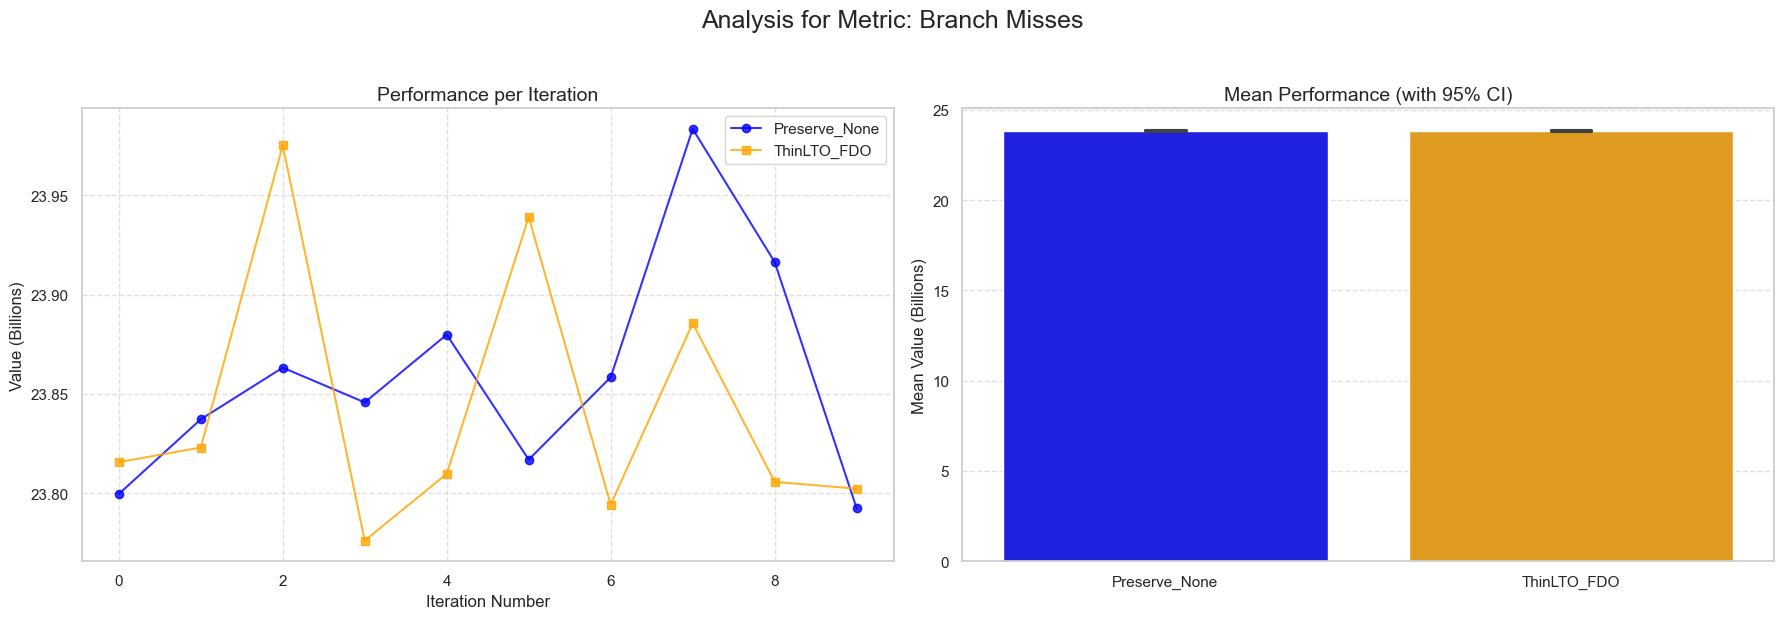


Branch Misses:
  Preserve_None             | Mean: 23859310556.4000 | Std Dev:   54469332.7193 | Runs: 10
  ThinLTO_FDO               | Mean: 23842632650.7000 | Std Dev:   63809189.4770 | Runs: 10
  Welch's T-test: p-value = 0.5585
  Conclusion: The difference is NOT statistically significant.

--------------------------------------------------------------------------------


--- Metric: Cycles ---


/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)
/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)


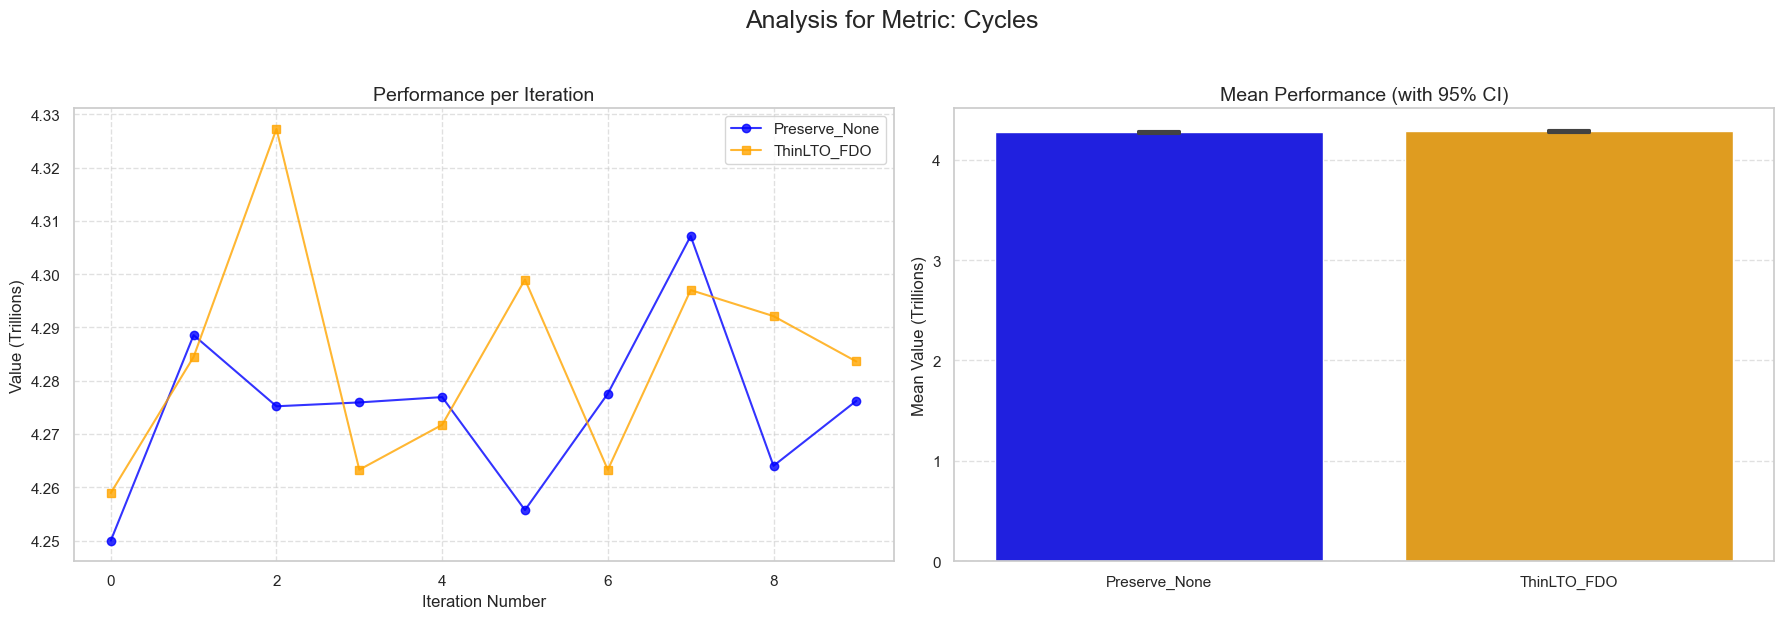


Cycles:
  Preserve_None             | Mean: 4274728116909.1001 | Std Dev: 15325157394.2358 | Runs: 10
  ThinLTO_FDO               | Mean: 4284071015858.3999 | Std Dev: 19927045987.7334 | Runs: 10
  Welch's T-test: p-value = 0.2805
  Conclusion: The difference is NOT statistically significant.

--------------------------------------------------------------------------------


--- Metric: Instructions ---


/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)
/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)


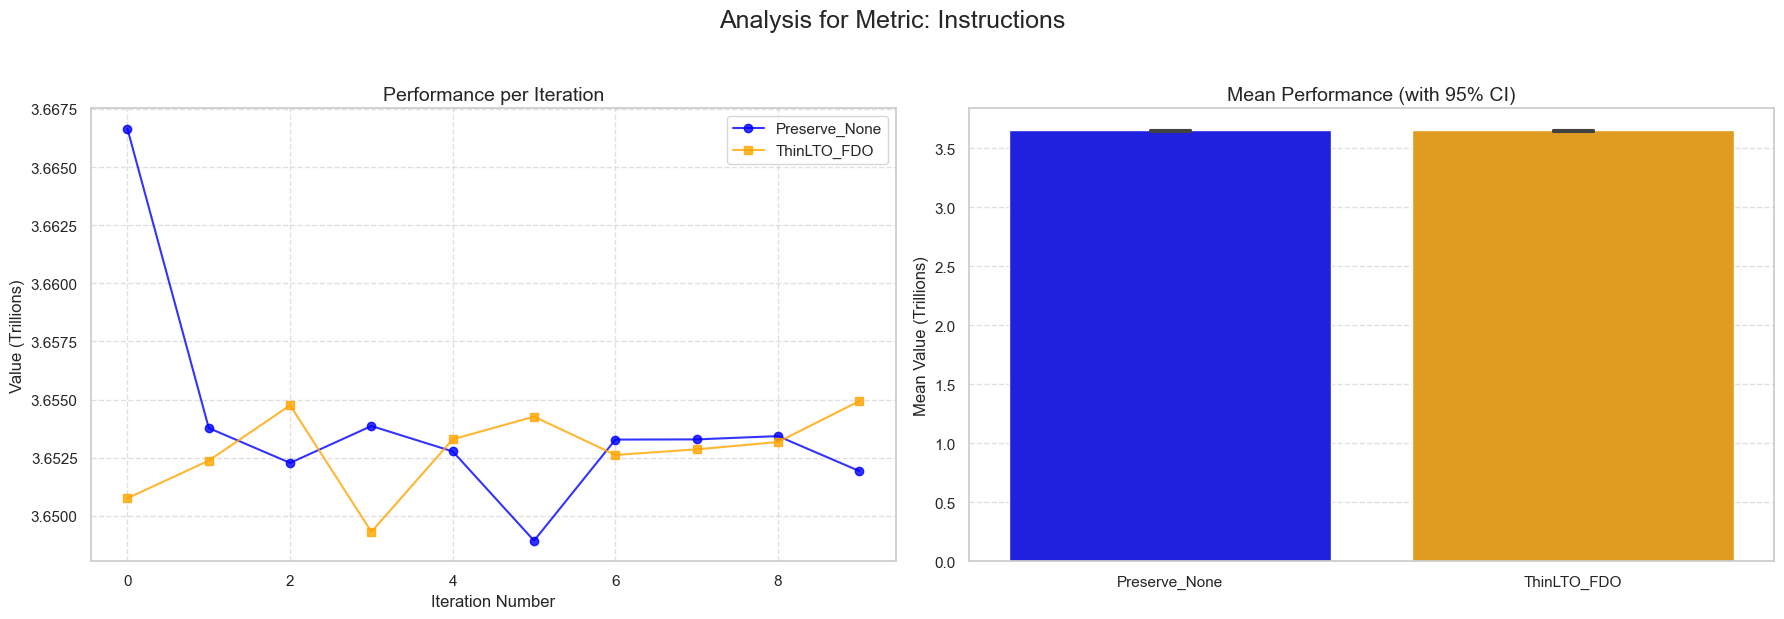


Instructions:
  Preserve_None             | Mean: 3654019777884.7002 | Std Dev: 4422319821.9061 | Runs: 10
  ThinLTO_FDO               | Mean: 3652836780236.7998 | Std Dev: 1656926207.2966 | Runs: 10
  Welch's T-test: p-value = 0.4675
  Conclusion: The difference is NOT statistically significant.

--------------------------------------------------------------------------------


--- Metric: Ipc ---


/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)
/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)


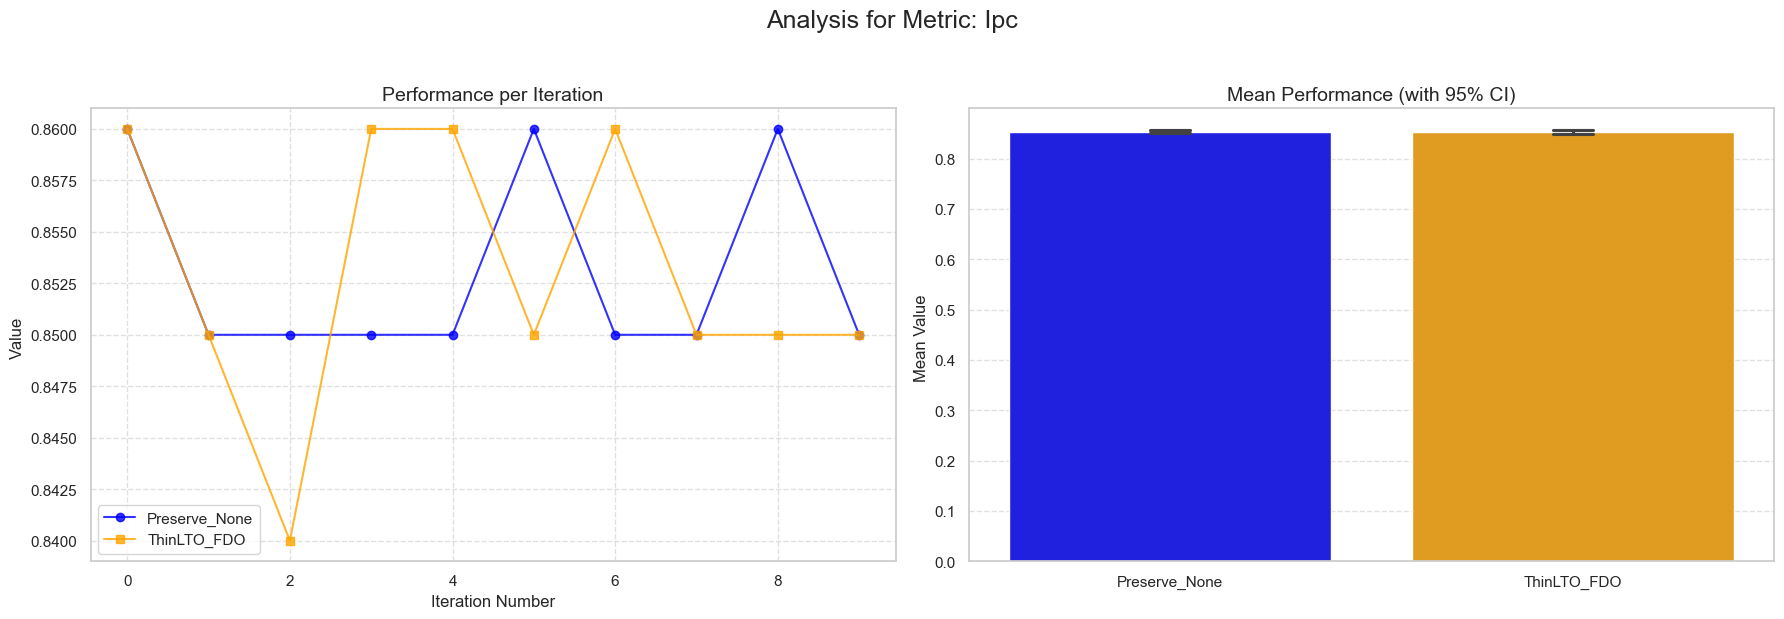


Ipc:
  Preserve_None             | Mean:          0.8530 | Std Dev:          0.0046 | Runs: 10
  ThinLTO_FDO               | Mean:          0.8530 | Std Dev:          0.0064 | Runs: 10
  Welch's T-test: p-value = 1.0000
  Conclusion: The difference is NOT statistically significant.

--------------------------------------------------------------------------------


--- Metric: Itlb Load Misses ---


/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)
/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)


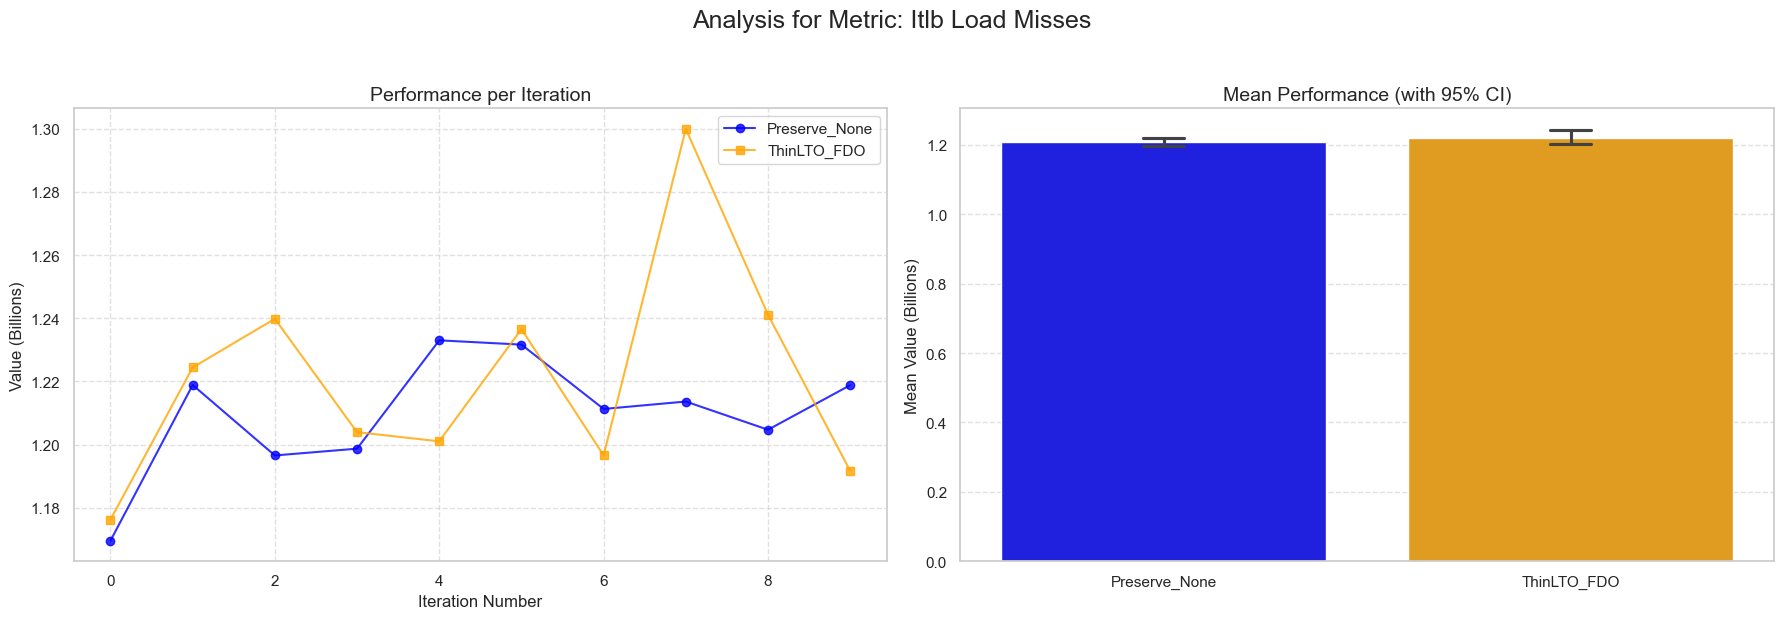


Itlb Load Misses:
  Preserve_None             | Mean: 1209665558.9000 | Std Dev:   17716071.8502 | Runs: 10
  ThinLTO_FDO               | Mean: 1221119461.1000 | Std Dev:   33757872.6607 | Runs: 10
  Welch's T-test: p-value = 0.3831
  Conclusion: The difference is NOT statistically significant.

--------------------------------------------------------------------------------


--- Metric: L1 Dcache Load Misses ---


/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)
/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)


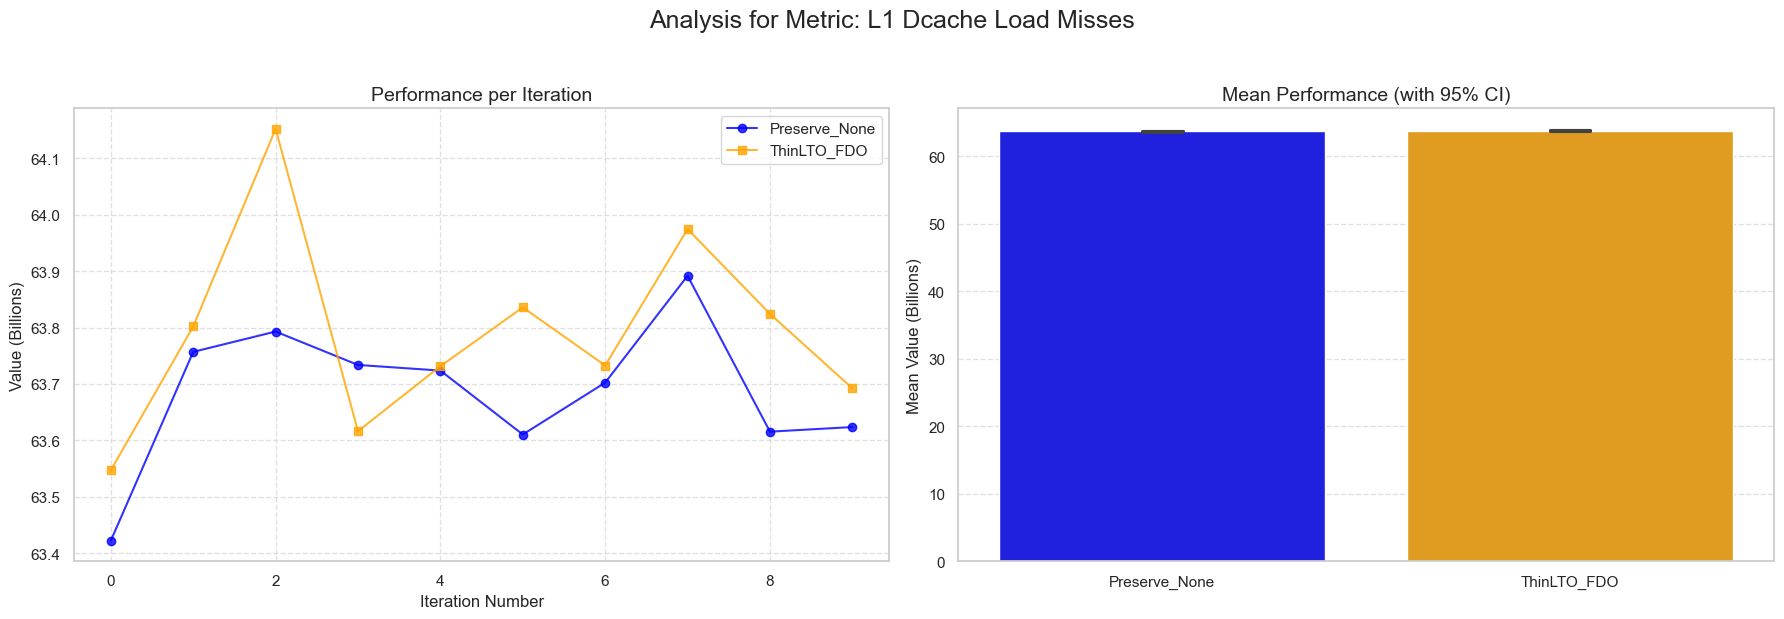


L1 Dcache Load Misses:
  Preserve_None             | Mean: 63687328704.0000 | Std Dev:  121127408.3994 | Runs: 10
  ThinLTO_FDO               | Mean: 63790789416.8000 | Std Dev:  165432109.2668 | Runs: 10
  Welch's T-test: p-value = 0.1490
  Conclusion: The difference is NOT statistically significant.

--------------------------------------------------------------------------------


--- Metric: L1 Icache Load Misses ---


/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)
/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)


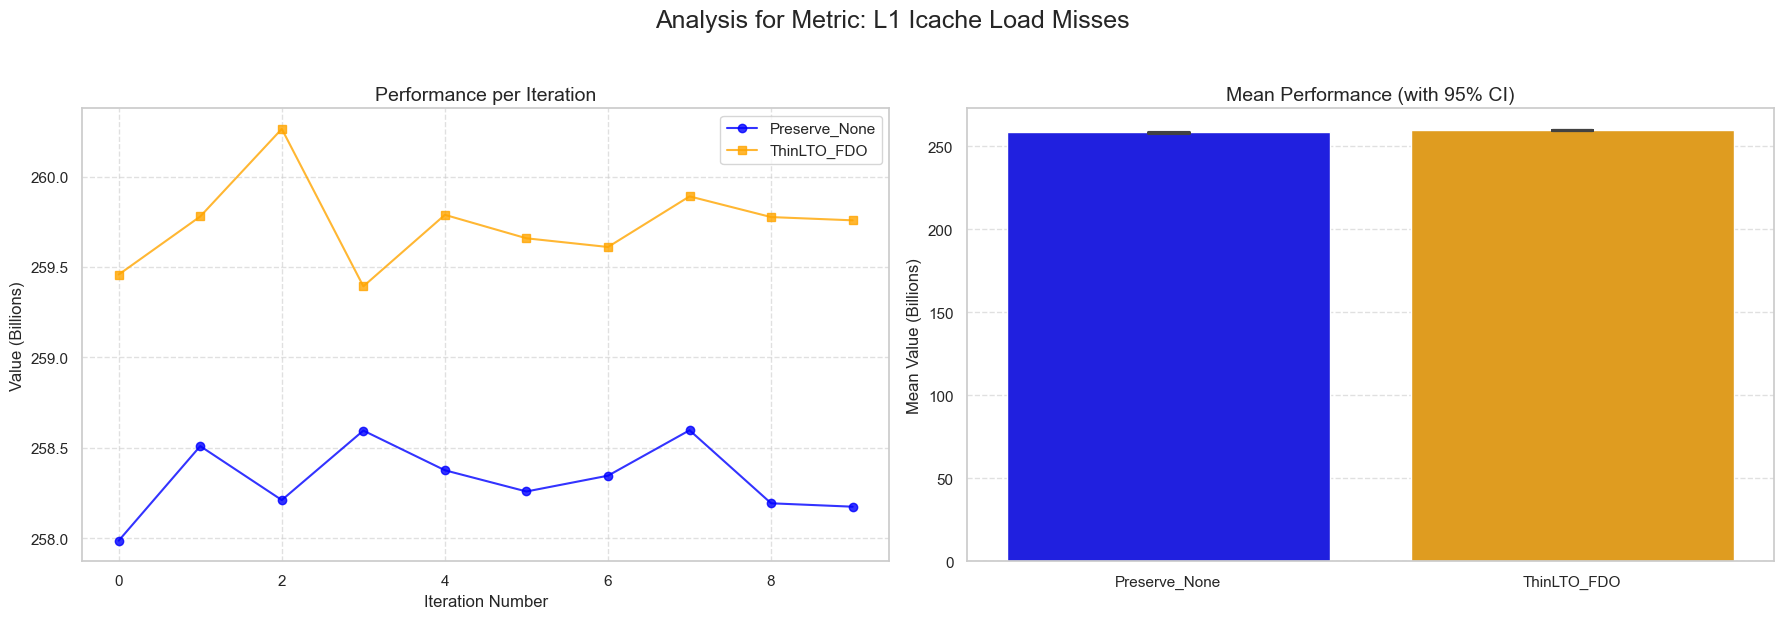


L1 Icache Load Misses:
  Preserve_None             | Mean: 258325720735.6000 | Std Dev:  188570504.4711 | Runs: 10
  ThinLTO_FDO               | Mean: 259737457012.9000 | Std Dev:  229029392.6245 | Runs: 10
  Welch's T-test: p-value = 0.0000
  Conclusion: The difference is STATISTICALLY SIGNIFICANT.
  -> 'Preserve_None' had significantly fewer (better) misses than 'ThinLTO_FDO'.

--------------------------------------------------------------------------------


--- Metric: Llc Load Misses ---


/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)
/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)


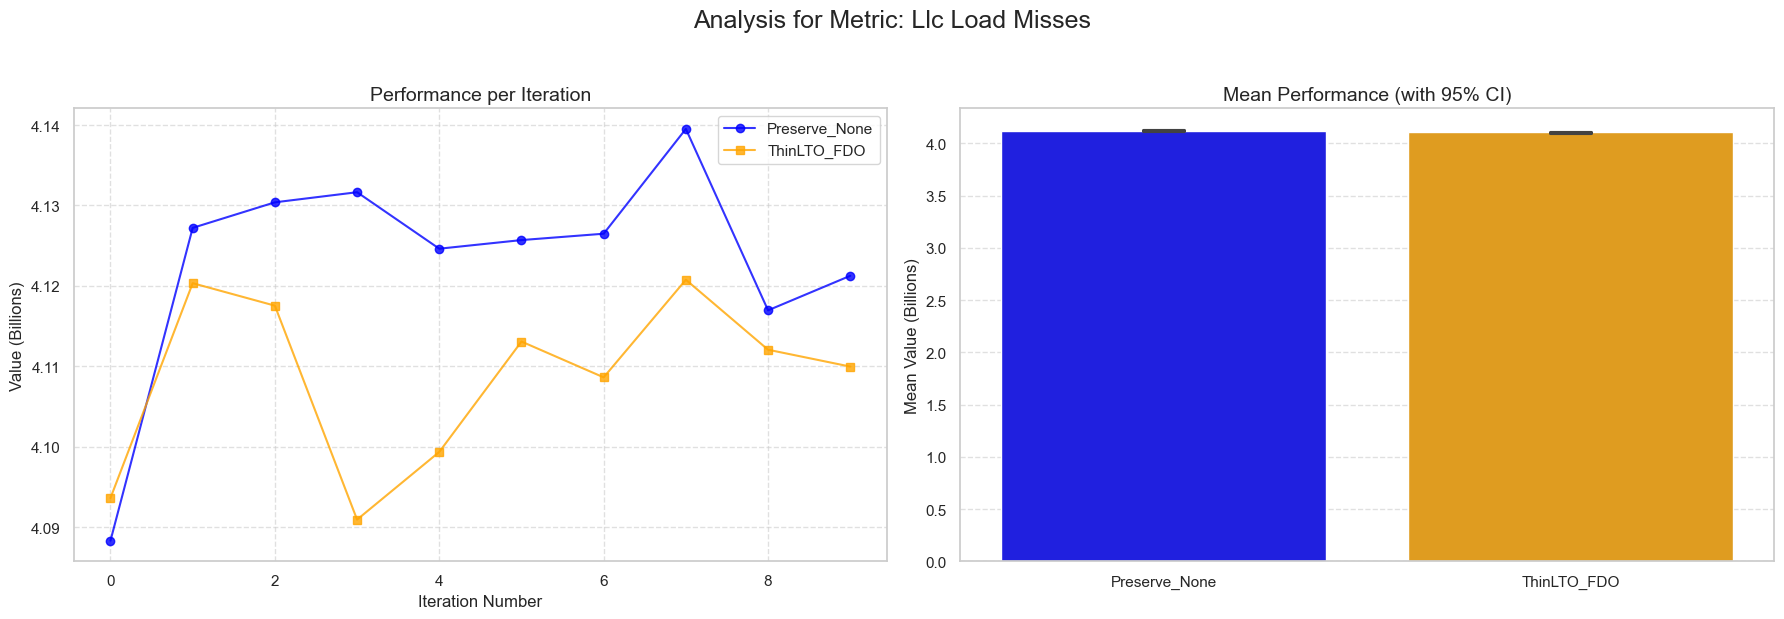


Llc Load Misses:
  Preserve_None             | Mean: 4123206354.5000 | Std Dev:   12980181.7463 | Runs: 10
  ThinLTO_FDO               | Mean: 4108619515.9000 | Std Dev:   10108713.9133 | Runs: 10
  Welch's T-test: p-value = 0.0165
  Conclusion: The difference is STATISTICALLY SIGNIFICANT.
  -> 'ThinLTO_FDO' had significantly more (worse) misses than 'Preserve_None'.

--------------------------------------------------------------------------------


--- Metric: Sys Time S ---


/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)
/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)


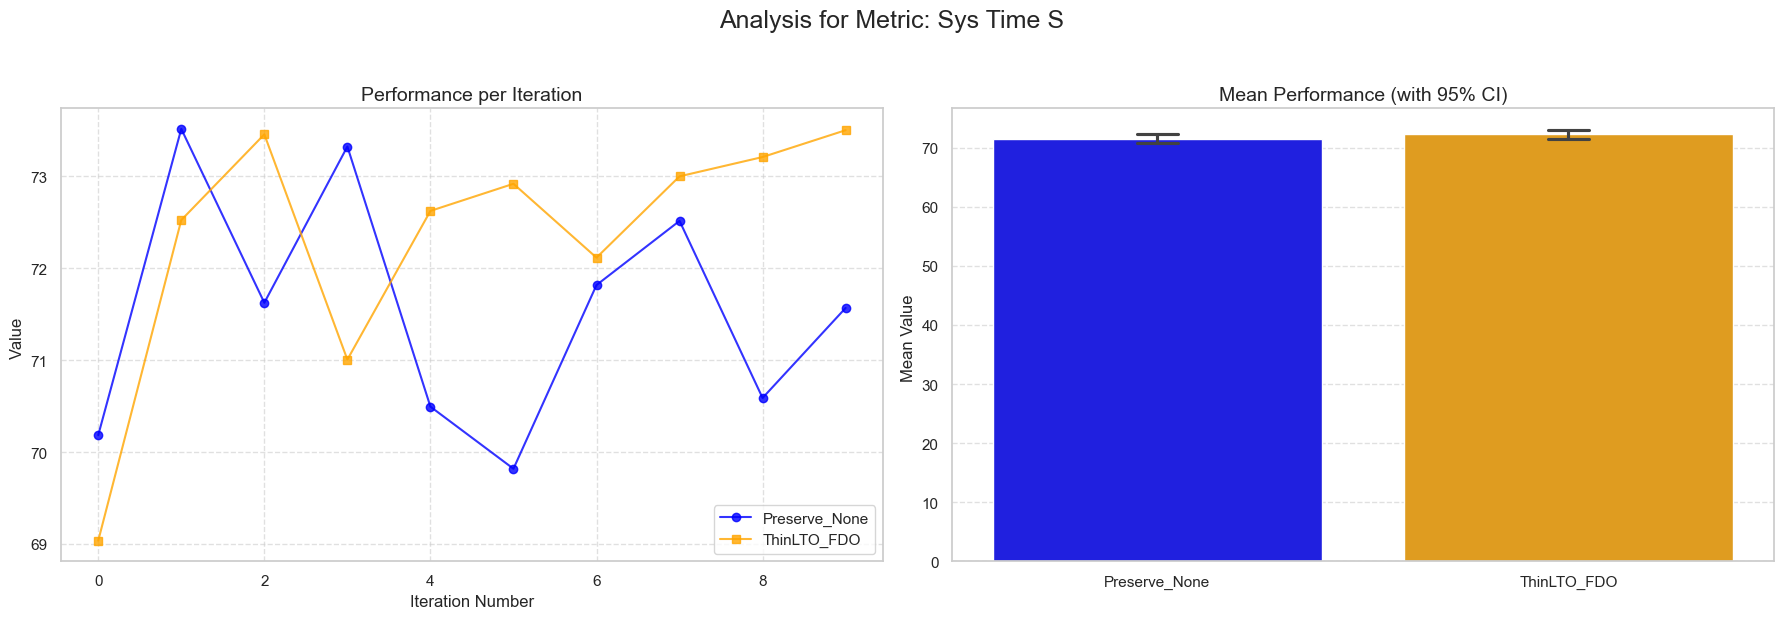


Sys Time S:
  Preserve_None             | Mean:         71.5455 | Std Dev:          1.2218 | Runs: 10
  ThinLTO_FDO               | Mean:         72.3398 | Std Dev:          1.3036 | Runs: 10
  Welch's T-test: p-value = 0.1990
  Conclusion: The difference is NOT statistically significant.

--------------------------------------------------------------------------------


--- Metric: Sys User Total Time S ---


/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)
/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)


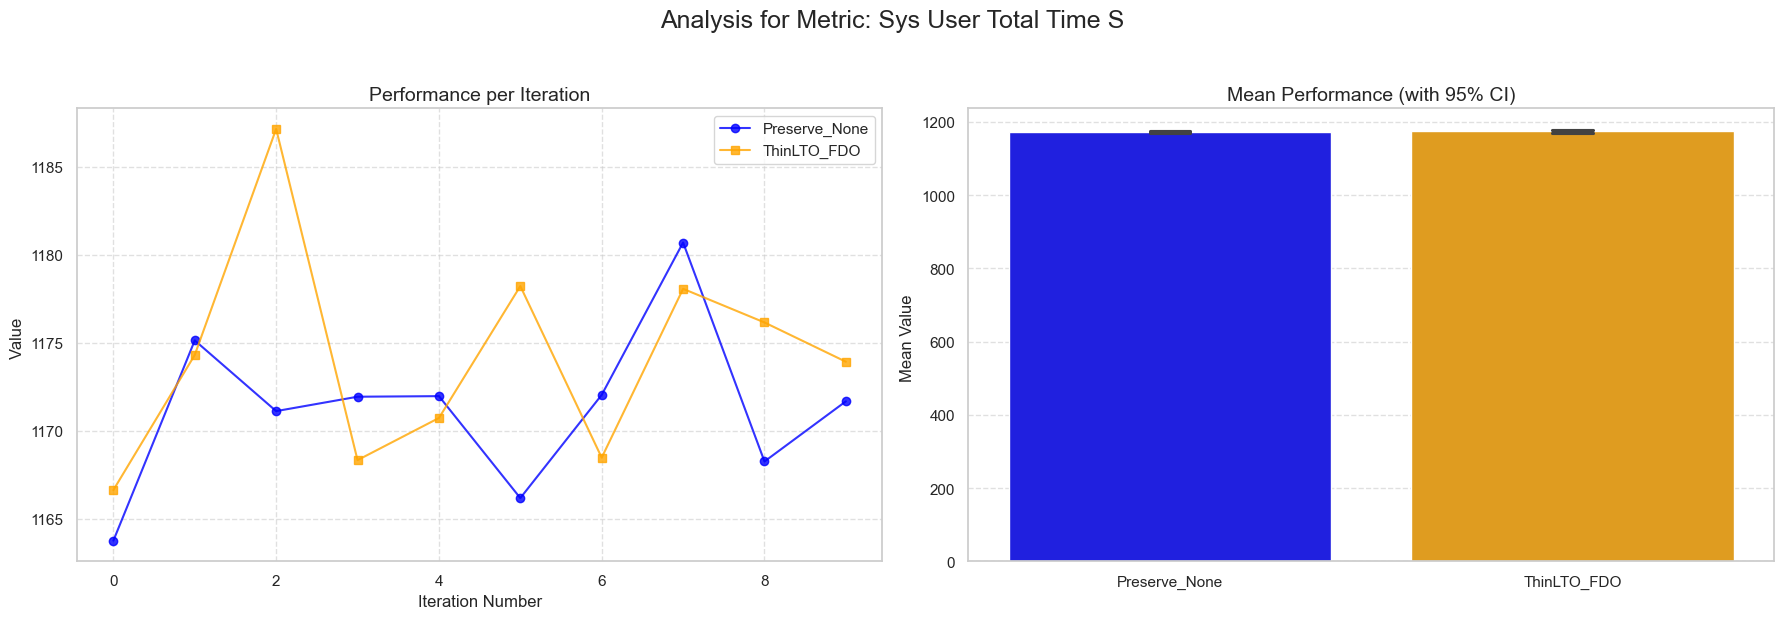


Sys User Total Time S:
  Preserve_None             | Mean:       1171.2773 | Std Dev:          4.4372 | Runs: 10
  ThinLTO_FDO               | Mean:       1174.2003 | Std Dev:          5.8238 | Runs: 10
  Welch's T-test: p-value = 0.2476
  Conclusion: The difference is NOT statistically significant.

--------------------------------------------------------------------------------


--- Metric: User Time S ---


/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)
/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)


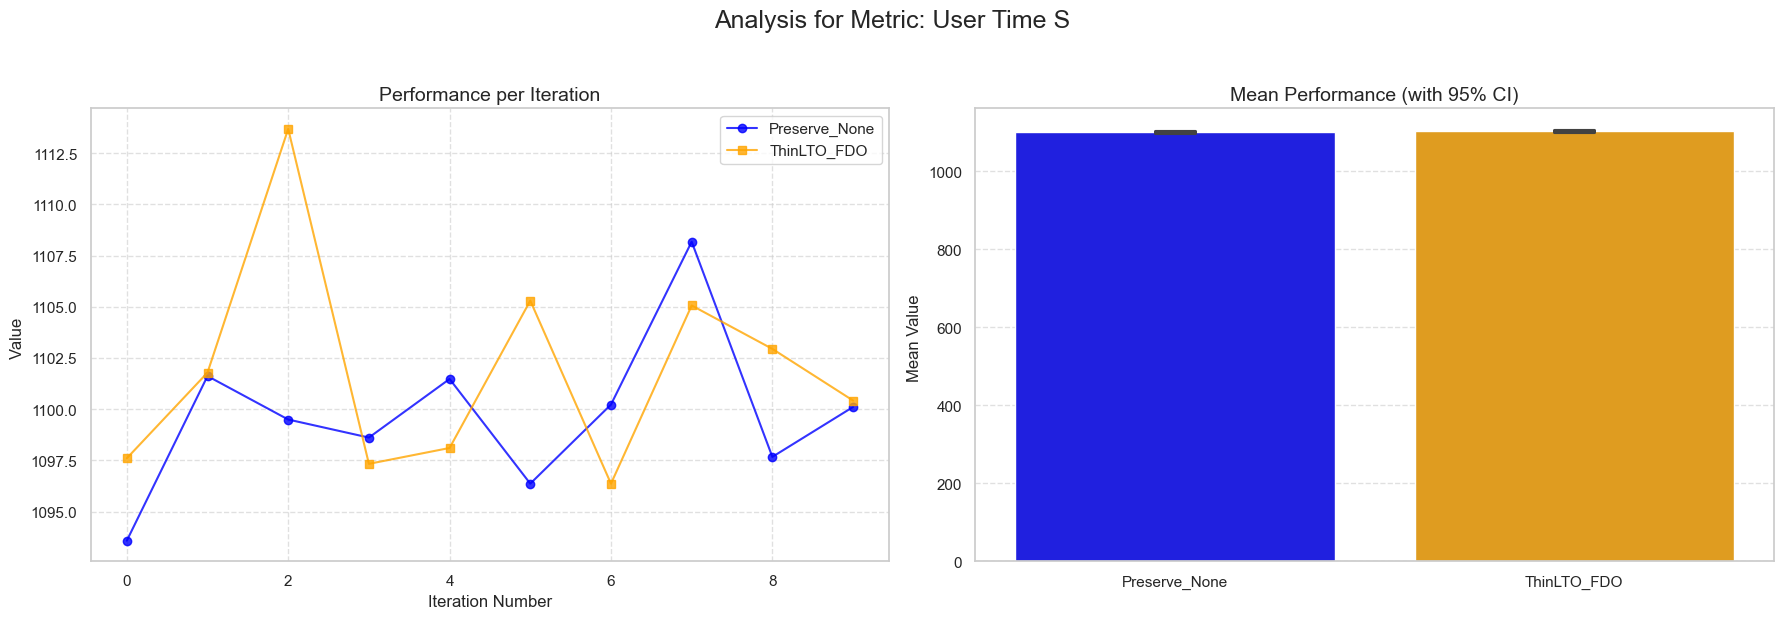


User Time S:
  Preserve_None             | Mean:       1099.7318 | Std Dev:          3.6495 | Runs: 10
  ThinLTO_FDO               | Mean:       1101.8605 | Std Dev:          4.9842 | Runs: 10
  Welch's T-test: p-value = 0.3162
  Conclusion: The difference is NOT statistically significant.

--------------------------------------------------------------------------------


--- Metric: Wall Time S ---


/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)
/tmp/ipykernel_3859840/4271586863.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x='label', y='value', data=df, capsize=0.1, palette=['blue', 'orange'], ci=95)


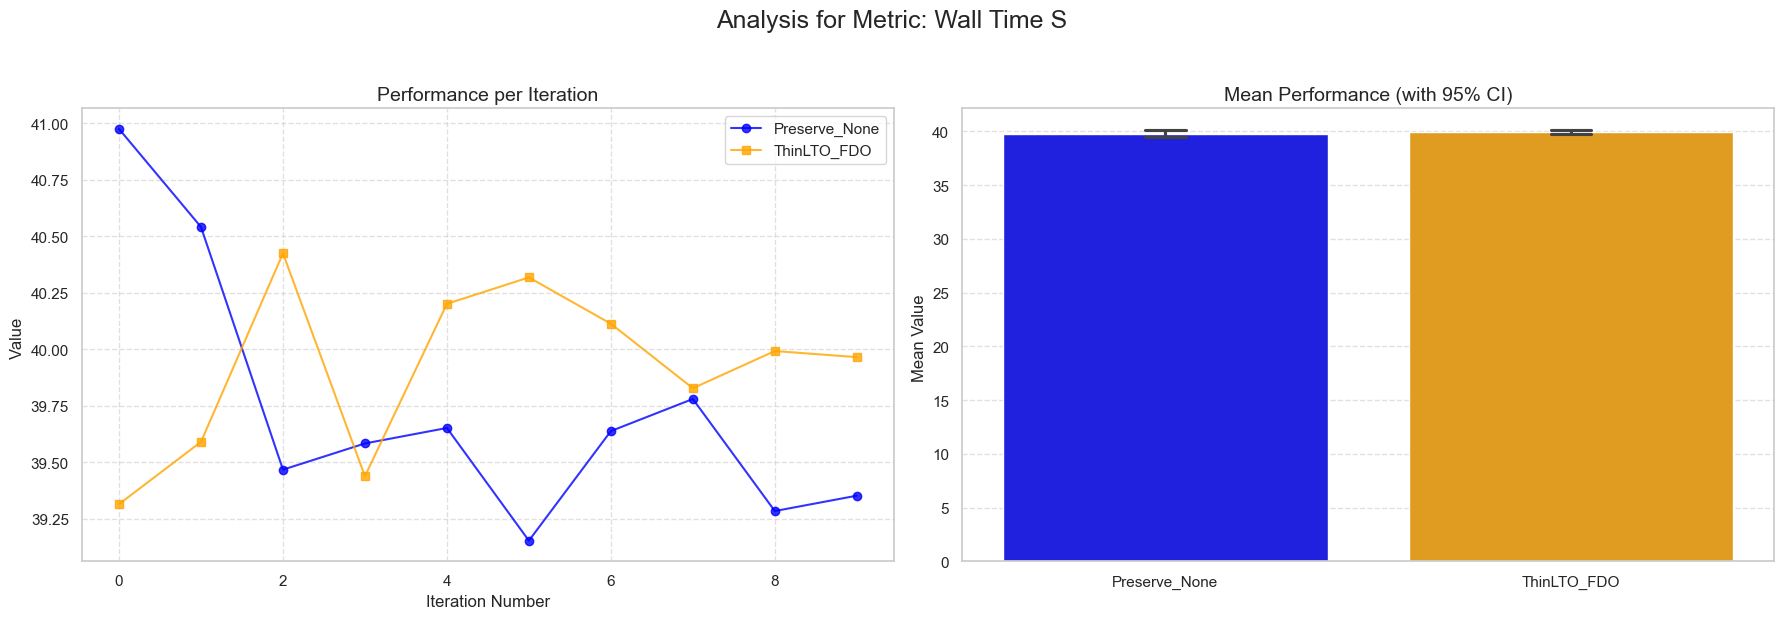


Wall Time S:
  Preserve_None             | Mean:         39.7427 | Std Dev:          0.5464 | Runs: 10
  ThinLTO_FDO               | Mean:         39.9185 | Std Dev:          0.3537 | Runs: 10
  Welch's T-test: p-value = 0.4301
  Conclusion: The difference is NOT statistically significant.

--------------------------------------------------------------------------------


✅ Notebook finished.


In [6]:
# --- RUN THE ANALYSIS ---
print("Starting analysis...")
all_benchmark_data = analyze_directory(RESULTS_DIR)
print("\nAnalysis complete. Generating visualizations...")

visualize_and_analyze(all_benchmark_data)

print("\n\n✅ Notebook finished.")